The equation
$$\frac{\partial x(t)}{\partial t}  = x(t)$$
has an unstable fixed point in $x(t)=0$.
The solutions are given by
$$x(t) = x_0e^t$$

In [1]:
%loadlibs

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


  0%|          | 0/25000 [00:00<?, ?it/s]

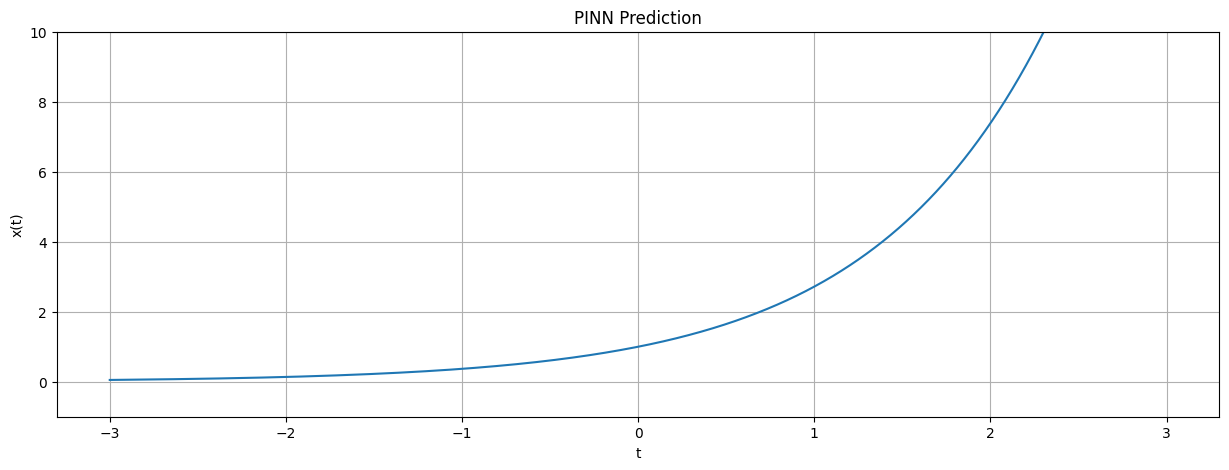

In [43]:
def pde_loss(model, t, x0):
    x_t = model(t, x0)
    lhs = torch.autograd.grad(x_t, t, torch.ones_like(t), create_graph=True)[0]
    rhs = x_t
    return ((lhs - rhs)**2).mean()

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_size = 20
        self.l1 = nn.Linear(1, self.layer_size)
        self.l2 = nn.Linear(self.layer_size, self.layer_size)
        self.l3 = nn.Linear(self.layer_size, self.layer_size)
        self.l4 = nn.Linear(self.layer_size, 1)
        self.activation = nn.Tanh()

    def forward(self, t, x0):
        x = self.activation(self.l1(t))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        x = self.l4(x)
        return x0 + self.activation(t) * x

n_epochs = 25000
n_points = 1024
t_max = 3
x0 = 1

model = Model()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for i in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t = ((torch.rand(n_points, requires_grad=True).unsqueeze(1))-0.5)*t_max*2
    loss = pde_loss(model, t, x0)
    loss.backward()
    if i%100 == 99:
        pbar.set_description(f"Loss: {loss.item():.3e}")
    optimizer.step()

plt.figure(figsize=(15, 5))
t = torch.linspace(-t_max, t_max, 10000)
plt.plot(t, model(t.unsqueeze(-1), x0).squeeze().detach())
plt.ylim([-1, 10])
plt.ylabel("x(t)")
plt.xlabel("t")
plt.title("PINN Prediction")
plt.grid()

plt.show()